In [230]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import io, img_as_float, img_as_ubyte, exposure
from scipy import ndimage
from skimage.restoration import denoise_tv_chambolle, denoise_nl_means, estimate_sigma
import cv2

In [231]:
img = io.imread('input.jpg')

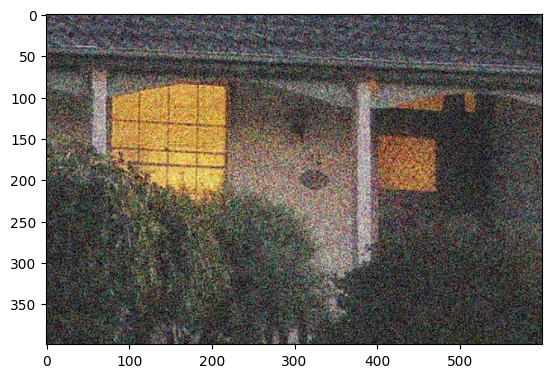

In [232]:
plt.imshow(img)

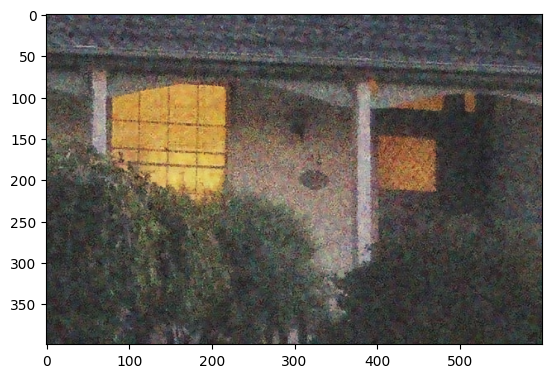

In [233]:
denoised = cv2.bilateralFilter(img,d=9,sigmaColor=75,sigmaSpace=75)
plt.imshow(denoised)

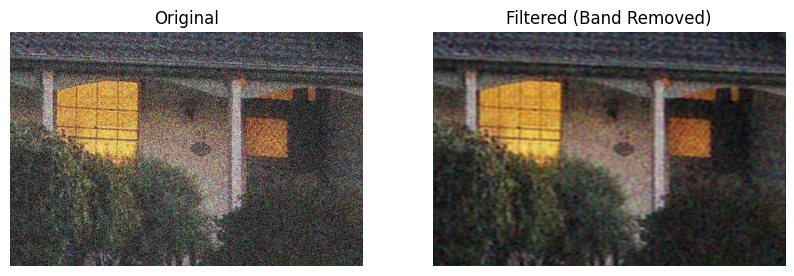

In [234]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def remove_frequency_band(image, r_min, r_max):
    """
    Remove frequencies between r_min and r_max (band-stop filter)
    from a colored image.
    """

    rows, cols, ch = image.shape
    crow, ccol = rows // 2, cols // 2

    # Create output image
    filtered_img = np.zeros_like(image, dtype=np.float32)

    for i in range(ch):  # Process each color channel separately
        channel = image[:, :, i]

        # FFT
        f = np.fft.fft2(channel)
        fshift = np.fft.fftshift(f)

        # Create mask
        mask = np.ones((rows, cols), np.uint8)

        for x in range(rows):
            for y in range(cols):
                dist = np.sqrt((x - crow)**2 + (y - ccol)**2)

                # Remove frequencies within the radius range
                if r_min <= dist <= r_max:
                    mask[x, y] = 0

        # Apply mask
        fshift_filtered = fshift * mask

        # Inverse FFT
        f_ishift = np.fft.ifftshift(fshift_filtered)
        img_back = np.fft.ifft2(f_ishift)
        img_back = np.abs(img_back)

        filtered_img[:, :, i] = img_back

    # Normalize result
    filtered_img = cv2.normalize(filtered_img, None, 0, 255, cv2.NORM_MINMAX)
    filtered_img = filtered_img.astype(np.uint8)

    return filtered_img


# -------------------------------
# Example usage
# -------------------------------
image = cv2.imread("input.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Define radius range to remove
r_min = 70   # inner radius
r_max = 400   # outer radius

filtered = remove_frequency_band(denoised, r_min, r_max)

# Display
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Filtered (Band Removed)")
plt.imshow(filtered)
plt.axis("off")

plt.show()

(-0.5, 599.5, 398.5, -0.5)

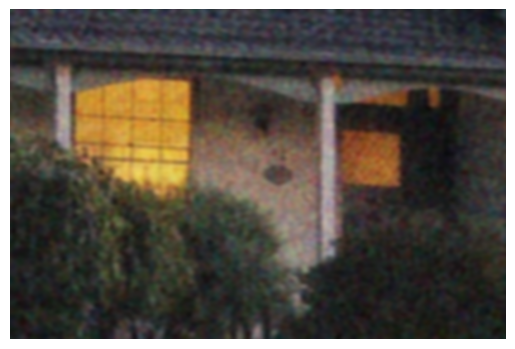

In [235]:
median_filter = np.zeros_like(filtered)

for i in range(3):  # RGB channels
    median_filter[:, :, i] = ndimage.gaussian_filter(filtered[:, :, i], sigma=2)

plt.imshow(median_filter.astype(np.uint8))
plt.axis('off')

(-0.5, 599.5, 398.5, -0.5)

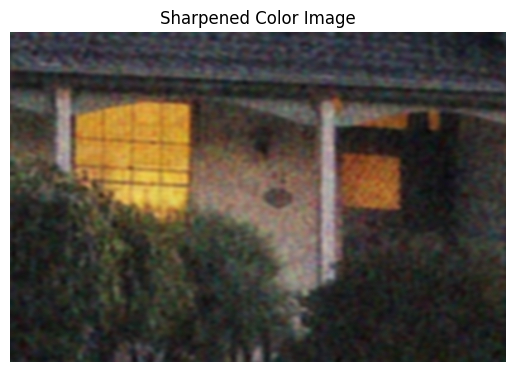

In [236]:
kernel = np.array([[0, -1, 0],
                   [-1, 5, -1], 
                   [0, -1, 0]])
# Create empty output
sharpened = np.zeros_like(median_filter)

# Apply convolution per channel
for i in range(3):  # RGB
    sharpened[:, :, i] = ndimage.convolve(median_filter[:, :, i], kernel)

# Clip values (VERY important)
sharpened = np.clip(sharpened, 0, 255)

# Show image
plt.imshow(sharpened.astype(np.uint8))
plt.title("Sharpened Color Image")
plt.axis('off')

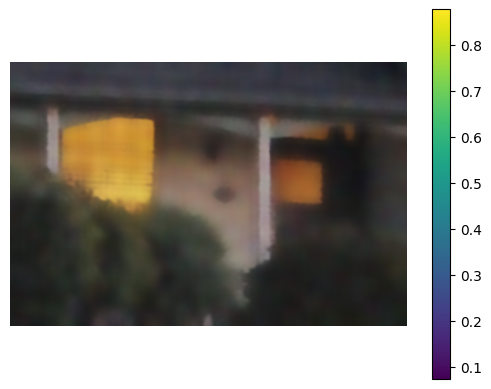

In [237]:
estimate_sigma = np.mean(estimate_sigma(sharpened, channel_axis=-1))
img_denoised1 = denoise_nl_means(sharpened, h=0.1 * estimate_sigma, fast_mode=False, patch_size=3, patch_distance=11, channel_axis=-1)
plt.imshow(img_denoised1)
plt.axis('off')
plt.colorbar()
plt.show()

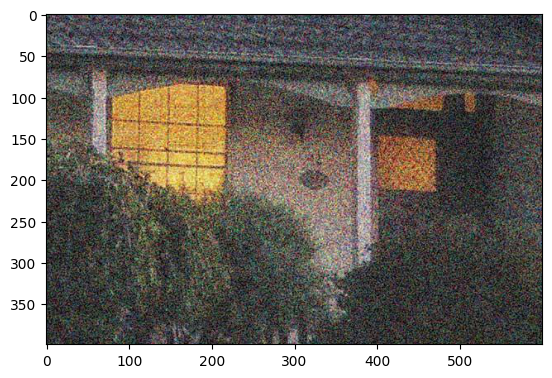

In [238]:
plt.imshow(image)

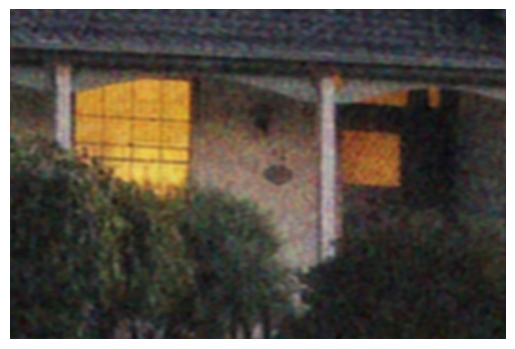

In [239]:
from skimage.restoration import denoise_tv_chambolle, denoise_nl_means, estimate_sigma
sharpened = img_as_float(sharpened)
est_sigma = np.mean(estimate_sigma(sharpened, channel_axis=-1))
img_denoised2 = denoise_nl_means(sharpened, h=0.75 * est_sigma, fast_mode=False, patch_size=3, patch_distance=11, channel_axis=-1)
plt.imshow(img_denoised2)
plt.axis('off')
plt.show()

(-0.5, 599.5, 398.5, -0.5)

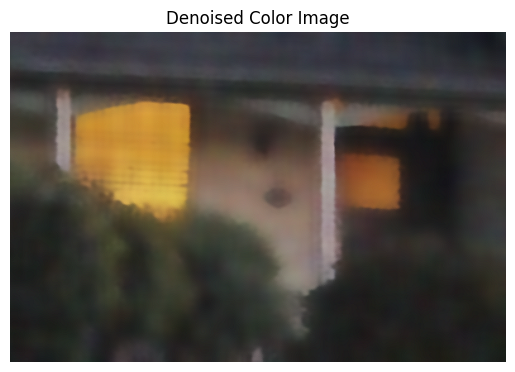

In [240]:
img_denoised1 = img_as_ubyte(img_denoised1)
for i in range(3):  # RGB
    img_denoised1[:, :, i] = ndimage.convolve(img_denoised1[:, :, i], kernel)

# Clip values (VERY important)
img_denoised1 = np.clip(img_denoised1, 0, 255)

# Show image
plt.imshow(img_denoised1.astype(np.uint8))
plt.title("Denoised Color Image")
plt.axis('off')

(-0.5, 599.5, 398.5, -0.5)

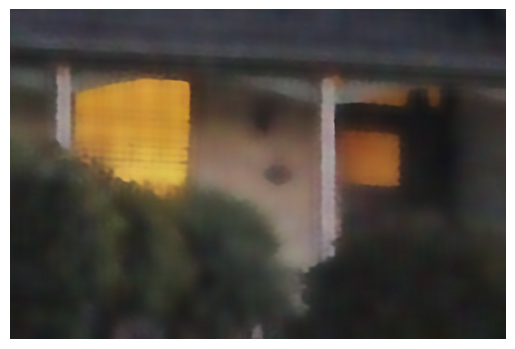

In [241]:
blur = cv2.GaussianBlur(img_denoised1, (5,5), 1)
sharpened = cv2.addWeighted(img_denoised1, 1.5, blur, -0.5, 0)
plt.imshow(sharpened.astype(np.uint8))
plt.axis('off')

(-0.5, 599.5, 398.5, -0.5)

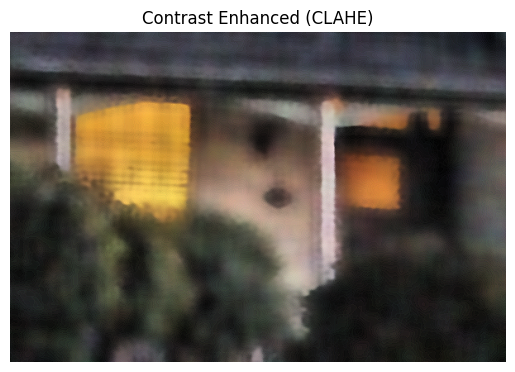

In [242]:
# Convert to float [0–1]
image_float = img_as_float(sharpened)

# Apply CLAHE
enhanced = exposure.equalize_adapthist(image_float, clip_limit=0.01)

plt.imshow(enhanced)
plt.title("Contrast Enhanced (CLAHE)")
plt.axis('off')

(-0.5, 599.5, 398.5, -0.5)

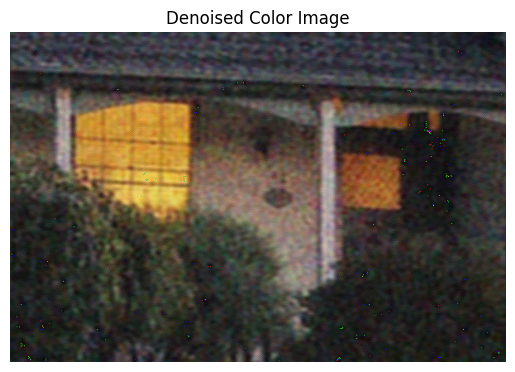

In [243]:
img_denoised2 = img_as_ubyte(img_denoised2)
for i in range(3):  # RGB
    img_denoised2[:, :, i] = ndimage.convolve(img_denoised2[:, :, i], kernel)

# Clip values (VERY important)
img_denoised2 = np.clip(img_denoised2, 0, 255)

# Show image
plt.imshow(img_denoised2.astype(np.uint8))
plt.title("Denoised Color Image")
plt.axis('off')

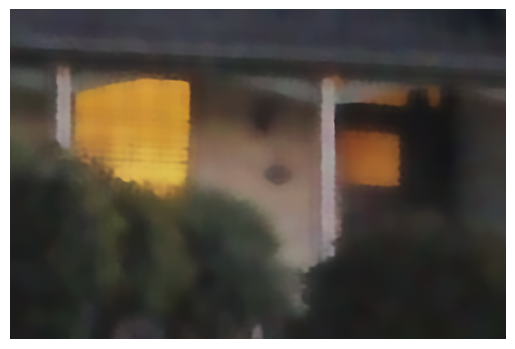

In [244]:
sharpened = img_as_float(sharpened)
estimate_sigma = np.mean(estimate_sigma(sharpened, channel_axis=-1))
img_denoised = denoise_nl_means(sharpened, h=1.15 * estimate_sigma, fast_mode=False, patch_size=3, patch_distance=11, channel_axis=-1)
plt.imshow(img_denoised)
plt.axis('off')
plt.show()

In [245]:
def adaptive_median_filter_gray(img, max_window_size=7):
    padded = np.pad(img, max_window_size//2, mode='edge')
    output = np.zeros_like(img)

    rows, cols = img.shape

    for i in range(rows):
        for j in range(cols):
            window_size = 3

            while True:
                half = window_size // 2
                r, c = i + max_window_size//2, j + max_window_size//2

                window = padded[r-half:r+half+1, c-half:c+half+1]

                Zmin = window.min()
                Zmax = window.max()
                Zmed = np.median(window)
                Zxy = padded[r, c]

                A1 = Zmed - Zmin
                A2 = Zmed - Zmax

                if A1 > 0 and A2 < 0:
                    B1 = Zxy - Zmin
                    B2 = Zxy - Zmax

                    if B1 > 0 and B2 < 0:
                        output[i, j] = Zxy
                    else:
                        output[i, j] = Zmed
                    break
                else:
                    window_size += 2
                    if window_size > max_window_size:
                        output[i, j] = Zmed
                        break
    return output


# RGB wrapper
def adaptive_median_filter_rgb(img, max_window_size=7):
    # Split channels
    channels = []
    
    for c in range(img.shape[2]):
        channel_filtered = adaptive_median_filter_gray(img[:, :, c], max_window_size)
        channels.append(channel_filtered)
    
    # Stack back into RGB image
    return np.stack(channels, axis=2)

C:\Users\elkha\AppData\Local\Temp\ipykernel_22716\2647279884.py:27: RuntimeWarning: overflow encountered in scalar subtract
  B2 = Zxy - Zmax


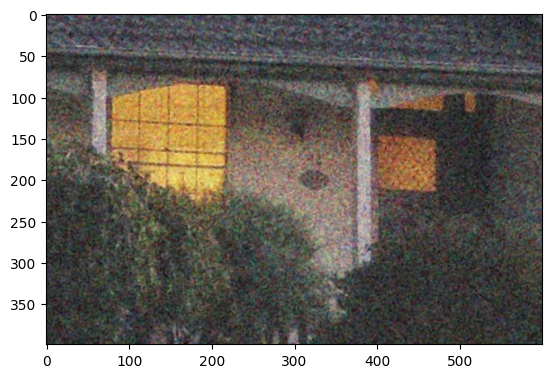

In [246]:
adaptive_median = adaptive_median_filter_rgb(img, max_window_size=12)
plt.imshow(adaptive_median)

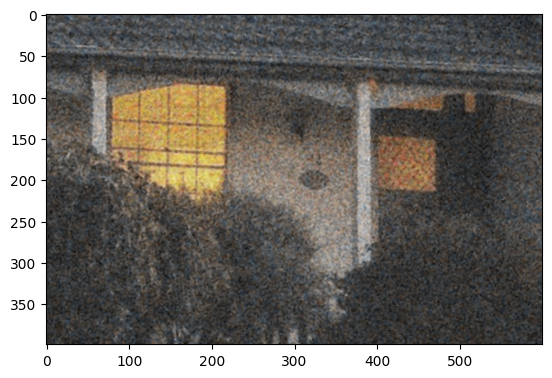

In [247]:
median_filter = ndimage.median_filter(img, size=3)
plt.imshow(median_filter)

(-0.5, 599.5, 398.5, -0.5)

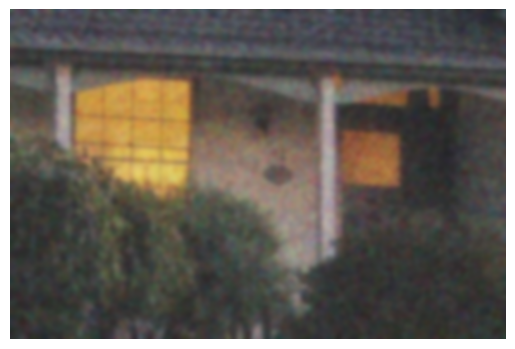

In [248]:
gaussian_image = np.zeros_like(img)

for c in range(3):
    gaussian_image[:, :, c] = ndimage.gaussian_filter(img[:, :, c], sigma=3)

plt.imshow(gaussian_image)# not prefered in this noise type
plt.axis('off')

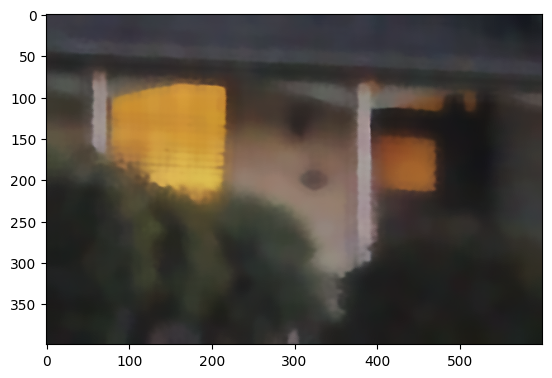

In [249]:
plt.imshow(img_denoised)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2602522642126061..1.2743591053865795].


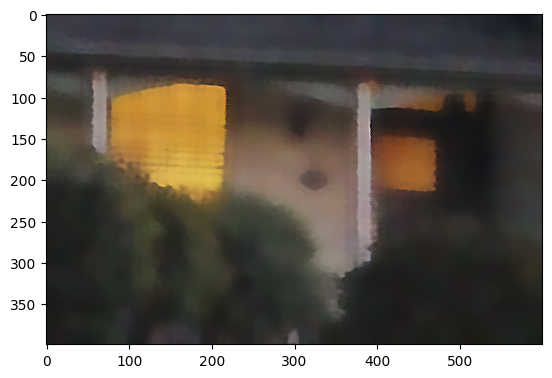

In [250]:
kernel = np.array([[0, -1, 0],
                   [-1, 5,-1],
                   [0, -1, 0]])

sharpened = cv2.filter2D(img_denoised, -1, kernel)
plt.imshow(sharpened)